# Image Preprocessing Research - Insects Detection

In this Notebook I will be exploring different preprocessing steps that exsist and answering research questions with those explorations. The aim is to narrow down certain preprocessing that can be applied to images before detection to help the detection step and furthermore if possible

## Executive summary
My research:
I concluded from my research that layers of filters can be applied to try to gain optimum results. My current working theory is applying bilateral gaussian to the images and then applying high contrast to reduce the noise and amplify the dark tones (bugs) and as a final step, I experimented with applying a median filter to reduce the peppered noise aka the dirt on the background which could help reduce false positives in the detection stage.

#### Sources of Research

Youtube Course by Shree Nayar
https://youtube.com/playlist?list=PL2zRqk16wsdorCSZ5GWZQr1EMWXs2TDeu&si=pi_N7SCXKlvx5YcM
This youtube playlist is a course for image preprocessing. 
It covers:
- Pixel Processing
- convolution
- deconvolution
- median filtering
- spacial gaussian
- brightness gausian
- bilateral gaussian (spacial + brightness)
- blur reduction

There were more but these are the ones I found relevant to this project in terms of experimenting.

Python article on Bilateral gaussian:
https://www.geeksforgeeks.org/python/python-bilateral-filtering/

Image enhancment techniques:
https://www.geeksforgeeks.org/machine-learning/image-enhancement-techniques-using-opencv-python/

Negative transformation of image:
https://www.geeksforgeeks.org/python/negative-transformation-of-an-image-using-python-and-opencv/

Median Filter: https://www.geeksforgeeks.org/python/spatial-filters-averaging-filter-and-median-filter-in-image-processing/

DINOV2 research:
Article: https://learnopencv.com/dinov2-self-supervised-vision-transformer/#data-pre-processing-and-usage-in-dinov2

Reseearch Paper: https://arxiv.org/abs/2304.07193

## Research questions

### What are different Preprocessing Techniques for images?
As mentioned in the sources there are many different image preprocessing methods that can be applied. We have mathematical equations we can apply to blur, deblur, remove motion blur and more. Then there are standardization methods which are a separate topic which we will cover. 
Below is a table presenting my findings from my research on Image preprocessing.

| name                | function                                                                                                                                                                                        | pros                                                                                                                               | cons                                                                                                                                                                         |
|---------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Pixel processing    | Transform the intensity of each pixel of f by applying T to achieve g                                                                                                                           | apply different calculations to f to achieve different results such as greyscale, lighten, darken, inverse, high and low contrast  |                                                                                                                                                                              |
| Gaussian Filter     | Adds a blur effect by utilizing a kernel for the spread of the gaussian. The value sigma in the formulae dictates how much spread the kernel upholds                                            | Removes noise from image by spreading a normalized value with the kernel.                                                          | Comes at the cost of details in the image such as edges and text. Refer to Bilateral Gaussian as the working solution                                                        |
| Median Filtering    | Possible solution for removing noise from an image                                                                                                                                              | Can help with removing peppered noise in an image                                                                                  | Not very useful as most images with noise have it across all pixels not just peppered in.                                                                                    |
| Bilateral Filtering | Apply Spacial and brightness gaussian to go pixel by pixel, apply the gaussian kernel but, check if there are pixels in the radius with extremely different values, exclude those in the kernel | Very useful for removing noise from and image whilst perserving details.                                                           | still costs some quality as it still applies the formula to each pixel but with correct value for sigma, there is a nice balance of no noise and good amount of detail left. |

Additionally, there are filters we can apply with pixel processing. In this notebook I will first make a hypothesis of the one I think will work best and then find research papers which explored the same problem and compare our findings. 

In image preprocessing. In the mathematical aspect, f(x,y) is the image. This understanding graphs it in a 2 dimensional manner.

| filter name   | function                                                                                                       | equation |
|---------------|----------------------------------------------------------------------------------------------------------------|----------|
| Darken        | Darkens image brightness, useful for highlighting bright subject in images with dark colored background        | f - 128  |
| Lighten       | Lightens image brightness, useful for highlighting dark subject in images with light colored background        | f + 128  |
| Invert        | Inverts the colors of the image                                                                                | 255 - f  |
| High Contrast | It amplifies the differences between dark and light tones in the image.                                        | f * 2    |
| Low Contrast  | It reduces the differences between the shadoews in the images and highlights. This makes the image appear flat | f/2      |

### What preprocessing steps does DINOV2 do to images?


Article: https://learnopencv.com/dinov2-self-supervised-vision-transformer/#data-pre-processing-and-usage-in-dinov2

Research Paper: https://arxiv.org/abs/2304.07193

In this article, we see that around 142 images were provided to the model to provide diversity and challenge it with real world representation.
Granted in the article it says that the authors of this research applied some preprocessing of their own by removing low-res images, removed duplicate images and images with sensitive content. They did not elaborate on what they meant by sensitive content. I have sourced the original papers pdf and will study it to find this. 

They applied de-duplication pipeline for near-matching images to be removed.
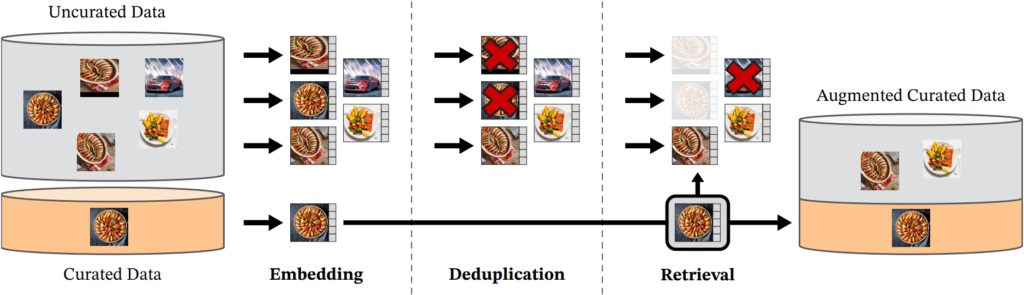

After further research, I have understood that DINOV2 does not apply preprocessing itself but it does currate a processing pipline to images for some standard processing. After looking at article online, I understand that it resizes images to   224x224 pixels and it applies a normalizing them using standard ImageNet statistics.

### Should these automatic preprocessing steps be fine-tuned for our data?
This pipeline seems to be automatic by DINOV2 itself, we will need to test this once were past the detection phase of this project and return to answer this question.

## Bilateral Gaussian Test
Bilateral gaussian is the mathematical practice of applying spatial gaussian and brightness gaussian by sliding a kernel across an image. I wont dive into its mathematical side as it gets complicated but this convolution method helps reduce noise whilst maintaining detail. Regular gaussian allows the kernel to blur the entire image whereas in bilateral, brightness gaussian is added to the formula, allowing the kernel to intreprit the value of the pixels it affects, and if the values of the pixels in the sigma (spread) are too far from the center pixel then they are excluded. This is an affective method of bluring noise out of an image whilst costing as little detail as needed.

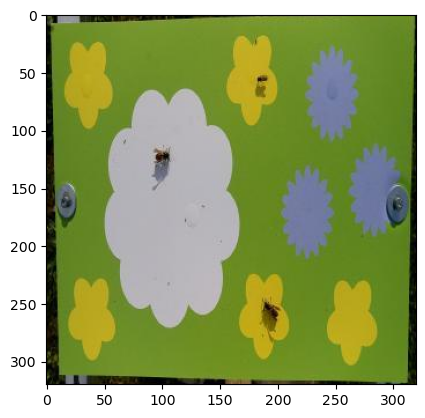

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('test images/2.jpg', 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

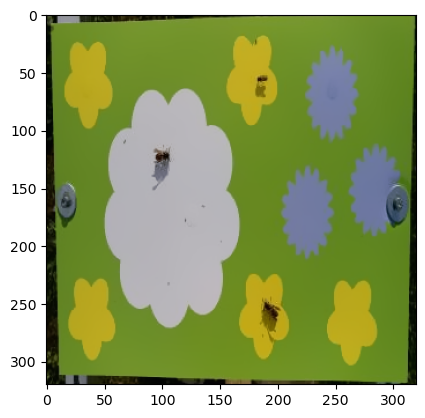

In [2]:
# Apply bilateral filter with d = 15, 
# sigmaColor = sigmaSpace = 75.
bilateral = cv2.bilateralFilter(img, 0, 15, 8)

# Save the output.
cv2.imwrite('2.2.jpg', bilateral)
plt.imshow(bilateral)

## Contrast Filter
Here I attempted to apply high contrast filter to help amplify the differences between the bugs and the brightly colored background to help with detection. 
High contrast can be applied as seen at the top of notebook, by applying the pixel processing formula f*2. f(x,y) is a function of an image in a 2d manner whilst giving each pixel a value for its intensity. Pixel processing opens the door to a variety of filtering or augmentations to this intensity such as grayscale, contrast, invert, raising certain rgb values and so on. In this case I have focused on high contrast but a list of pixel processings that I found from my research can be found above.

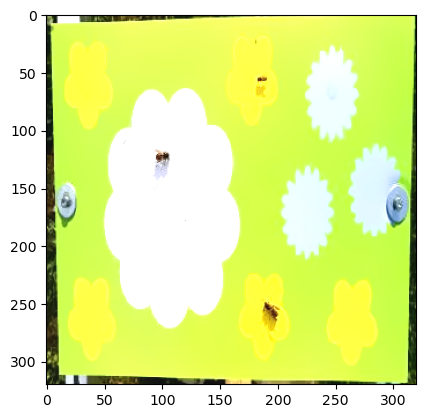

In [9]:
brightness = 10 
contrast = 2 
image2 = cv2.addWeighted(bilateral, contrast, np.zeros(bilateral.shape, bilateral.dtype), 0, brightness)
plt.imshow(image2)


## Invert RGB values
Here I attempted the previously mentioned invert filter post high contrast filter to see if the bugs could be high lighted but this test proved unfeasable. This will pave away from the direction of this notebook which is to help the detection model by directly removing feature uniqueness whilst also adding confusion for the model's understanding by painting the shadows a similar bright color as the bugs themselves.

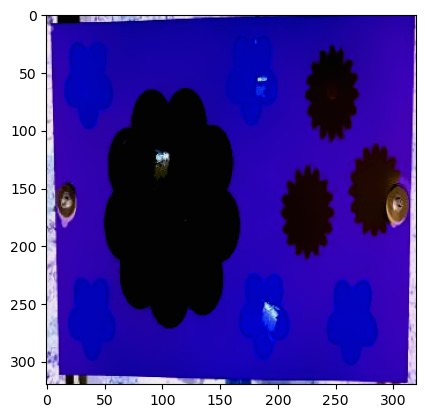

In [4]:
imgneg = 1 - image2
plt.imshow(imgneg)

I reapplied the same bilateral and high contrast + brightness code to a higher resolution image as our current test set includes images that are 320x320 and that does not allow me to intreprit the loss of image detail properly.

In [5]:
img4 = cv2.imread('test images/3.jpg', 1)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)
bilateral2 = cv2.bilateralFilter(img4, 0, 15, 8)
#brightness = 10 
contrast = 1.4
image5 = cv2.addWeighted(bilateral2, contrast, np.zeros(bilateral2.shape, bilateral2.dtype), 0, brightness)

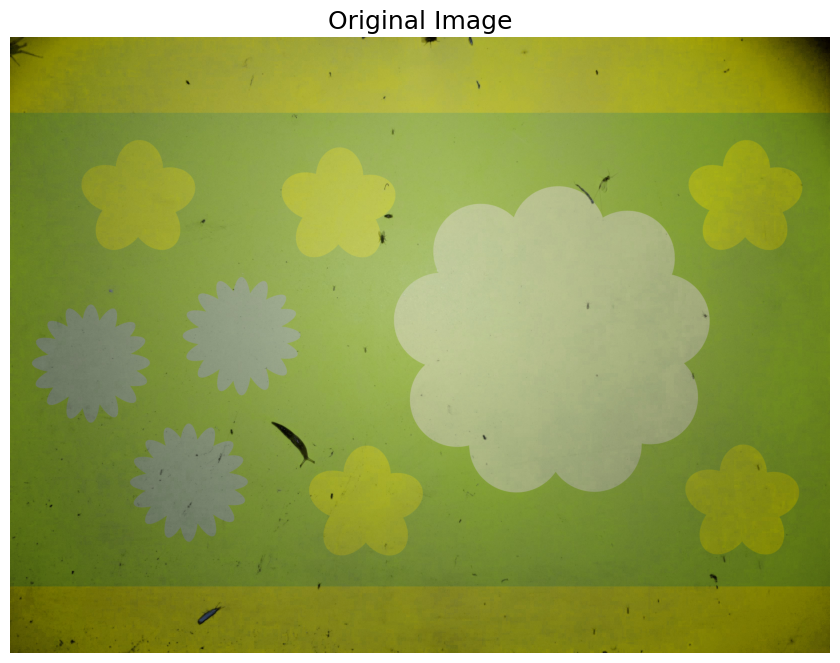

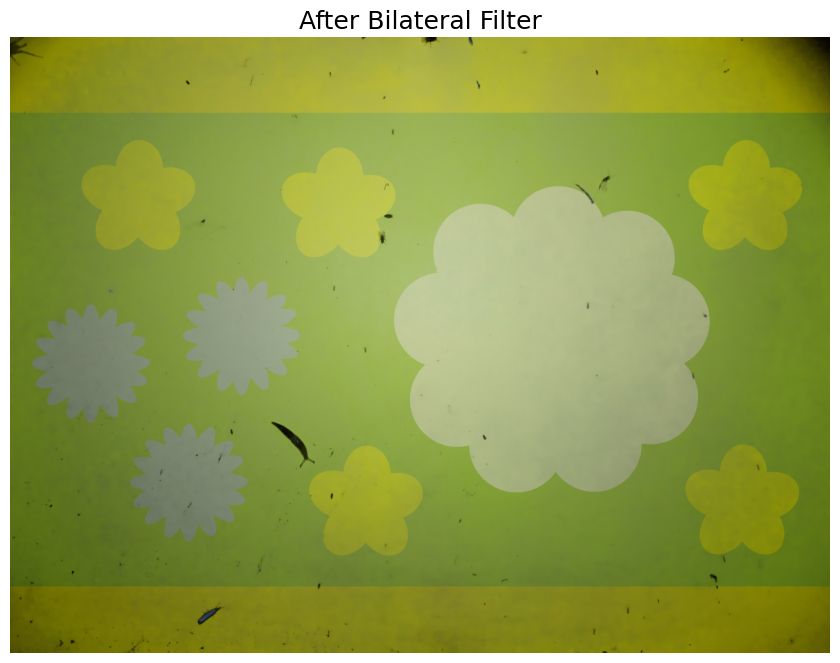

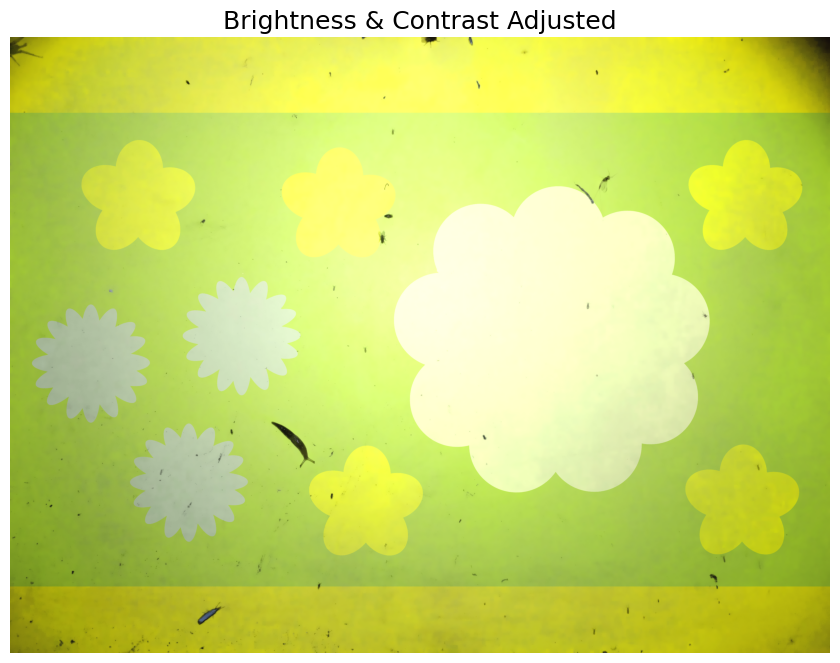

In [6]:
# Function to show image full-size
def show_full(img, title):
    plt.figure(figsize=(12, 8))  # 🔹 Adjust as needed for bigger view
    plt.imshow(img)
    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.show()

# Display images separately
show_full(img4, "Original Image")
show_full(bilateral2, "After Bilateral Filter")
show_full(image5, "Brightness & Contrast Adjusted")

## Median Filtering
Im applying median filtering in hopes to remove the "peppered" dirt from the image to reduct chances of confusion for detection models

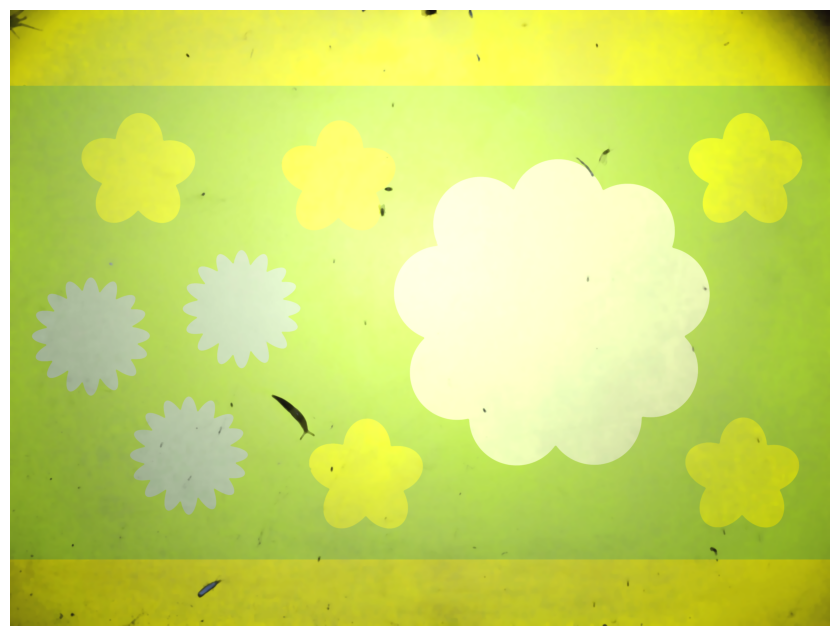

In [7]:
# Apply median filter to remove small dirt or bugs
median = cv2.medianBlur(image5, ksize=9)  # Try 3, 5, or 7 for different strengths

# Save or display
plt.figure(figsize=(12, 8))
plt.imshow(median)
plt.axis("off")
plt.show()